In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # For better confusion matrix visualization
from PIL import Image  # For loading custom images


In [2]:
# Load the MNIST dataset (60,000 training + 10,000 test images)
(x_train, y_train), (x_test, y_test) = mnist.load_data()


# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for CNN input: (28, 28, 1) for grayscale images
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [3]:
# Convert labels to one-hot encoding (10 classes: 0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Display dataset overview
print("Dataset Overview:")
print(f"Training data shape: {x_train.shape}, Labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}, Labels shape: {y_test.shape}")

Dataset Overview:
Training data shape: (60000, 28, 28, 1), Labels shape: (60000, 10)
Test data shape: (10000, 28, 28, 1), Labels shape: (10000, 10)


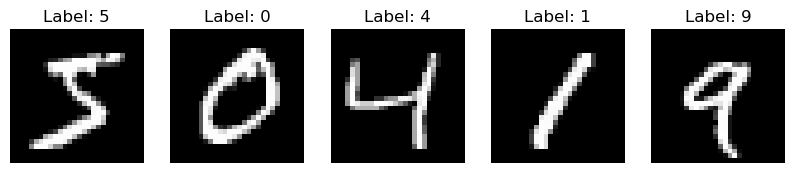

In [4]:
# Visualize a few sample images
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(x_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Label: {np.argmax(y_train[i])}")
    axes[i].axis('off')
plt.show()

In [5]:
# Define the CNN model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Convolutional layer
    MaxPooling2D((2, 2)),  # Pooling layer
    Conv2D(64, (3, 3), activation='relu'),  # Another conv layer
    MaxPooling2D((2, 2)),  # Another pooling layer
    Flatten(),  # Flatten for dense layers
    Dense(64, activation='relu'),  # Fully connected layer
    Dense(10, activation='softmax')  # Output layer (10 classes)
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

C:\Users\sriha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=10,  # You can increase for better accuracy
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

# Save the model (optional, for later use)
model.save('mnist_cnn_model.h5')
print("Model trained and saved as 'mnist_cnn_model.h5'")

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9267 - loss: 0.2437 - val_accuracy: 0.9798 - val_loss: 0.0626
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9813 - loss: 0.0628 - val_accuracy: 0.9869 - val_loss: 0.0402
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9864 - loss: 0.0432 - val_accuracy: 0.9893 - val_loss: 0.0336
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9896 - loss: 0.0339 - val_accuracy: 0.9888 - val_loss: 0.0332
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9916 - loss: 0.0270 - val_accuracy: 0.9873 - val_loss: 0.0396
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9939 - loss: 0.0206 - val_accuracy: 0.9896 - val_loss: 0.0337
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9949 - loss: 0.0169 - val_accuracy: 0.9888 - val_loss: 0.0354
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9956 - loss: 0.0139 - 

Model trained and saved as 'mnist_cnn_model.h5'


CNN Test Accuracy: 0.9905
CNN Test Loss: 0.0344


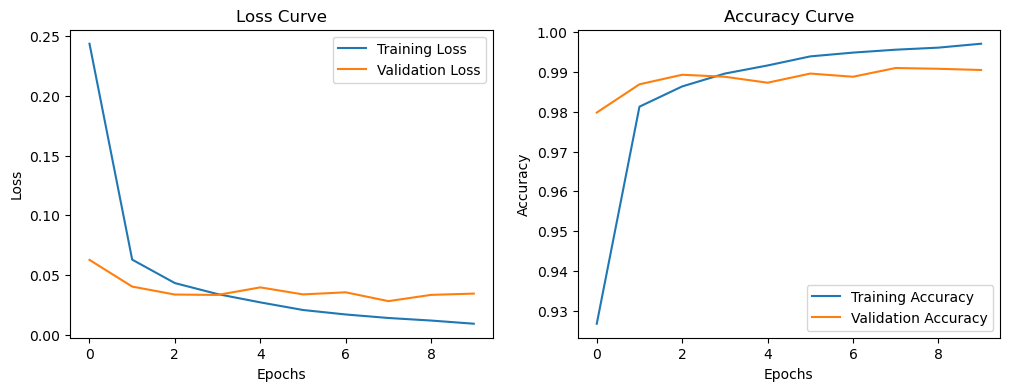

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


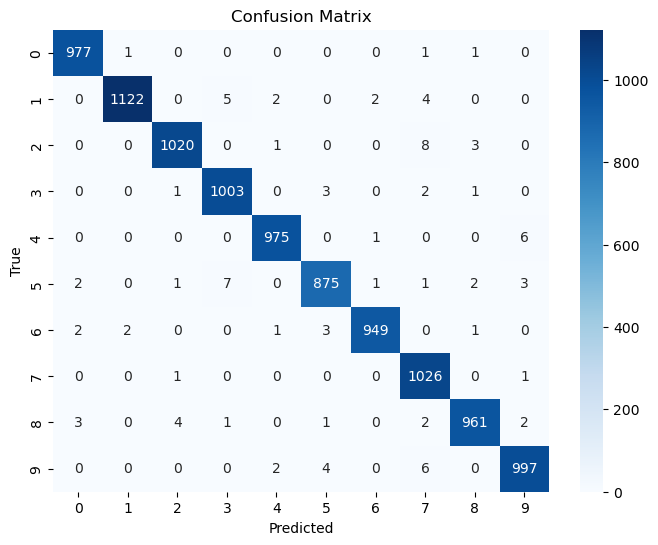

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.98       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [7]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.4f}")
print(f"CNN Test Loss: {test_loss:.4f}")

# Plot training and validation loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Generate predictions for confusion matrix
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

In [8]:
# Build a simple Multilayer Perceptron (MLP) for comparison
mlp_model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # Flatten the input
    Dense(128, activation='relu'),  # Hidden layer
    Dense(10, activation='softmax')  # Output layer
])

# Compile the MLP
mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the MLP
mlp_history = mlp_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

# Evaluate MLP
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(x_test, y_test, verbose=0)
print(f"MLP Test Accuracy: {mlp_test_acc:.4f}")
print(f"MLP Test Loss: {mlp_test_loss:.4f}")

# Compare accuracies
print(f"\nComparison: CNN Accuracy: {test_acc:.4f}, MLP Accuracy: {mlp_test_acc:.4f}")

Epoch 1/10


C:\Users\sriha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9017 - loss: 0.3568 - val_accuracy: 0.9447 - val_loss: 0.1890
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9539 - loss: 0.1606 - val_accuracy: 0.9617 - val_loss: 0.1312
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9664 - loss: 0.1158 - val_accuracy: 0.9675 - val_loss: 0.1103
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9734 - loss: 0.0902 - val_accuracy: 0.9711 - val_loss: 0.0953
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9791 - loss: 0.0723 - val_accuracy: 0.9733 - val_loss: 0.0875
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9826 - loss: 0.0605 - val_accuracy: 0.9744 - val_loss: 0.0855
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9854 - loss: 0.0507 - val_accuracy: 0.9748 - val_loss: 0.0802
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9875 - loss: 0.0436 - val_accuracy: 0.9775 - val_

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model  # If needed to reload the model

# Load the model if not already in memory (uncomment if restarting notebook)
# model = load_model('mnist_cnn_model.h5')

# Function to predict a digit from a custom image with debugging
def predict_digit(image_path, invert=False):
    try:
        # Load the original image
        img = Image.open(image_path)
        
        # Optional: Invert the image (if digits are black on white, make them white on black)
        if invert:
            img = Image.eval(img, lambda x: 255 - x)  # Invert colors
        
        # Convert to grayscale and resize
        img_gray = img.convert('L').resize((28, 28))
        img_array = np.array(img_gray).reshape(1, 28, 28, 1).astype('float32') / 255.0
        
        # Predict using the trained CNN model
        prediction = model.predict(img_array)
        predicted_digit = np.argmax(prediction)
        confidence = np.max(prediction) * 100  # Convert to percentage
        
        # Display original and processed images side-by-side for debugging
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        
        # Original image
        axes[0].imshow(img.convert('L'), cmap='gray')  # Show as grayscale
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # Processed image (what the model sees)
        axes[1].imshow(img_array.reshape(28, 28), cmap='gray')
        axes[1].set_title(f"Processed (Model Input)\nPredicted: {predicted_digit} ({confidence:.2f}%)")
        axes[1].axis('off')
        
        plt.show()
        
        # Print results
        print(f"Predicted Digit: {predicted_digit}")
        print(f"Confidence: {confidence:.2f}%")
        
        # Show top 3 predictions for insight
        top_indices = np.argsort(prediction[0])[::-1][:3]
        print("Top 3 Predictions:")
        for i, idx in enumerate(top_indices):
            print(f"  {i+1}. Digit {idx}: {prediction[0][idx] * 100:.2f}%")
        
    except Exception as e:
        print(f"Error loading or predicting image: {e}. Ensure the file path is correct and the image is a valid grayscale digit image.")

# Example usage
# predict_digit(r'C:\Users\sriha\Downloads\sample_digit.png', invert=False)  # Try without invert first
# predict_digit(r'C:\Users\sriha\Downloads\sample_digit.png', invert=True)   # Try with invert if needed


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


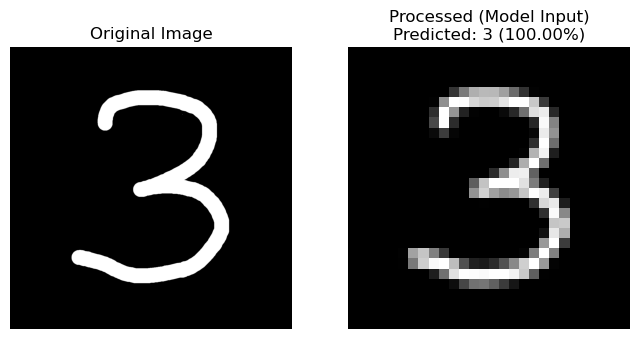

Predicted Digit: 3
Confidence: 100.00%
Top 3 Predictions:
  1. Digit 3: 100.00%
  2. Digit 8: 0.00%
  3. Digit 9: 0.00%


In [18]:
predict_digit(r'C:\Users\sriha\Downloads\sample_digit.png')